# Week 6 – Day 1
# Time Series Fundamentals

**Name:** Mohit Singh

## Objective

The objective of this notebook is to prepare stock price data for time series analysis.

In this notebook, we will:

- Download Reliance stock data.
- Convert the dataset into a DatetimeIndex.
- Resample daily data into weekly and monthly frequencies.
- Create lag features (Lag-1, Lag-5, Lag-21) for future forecasting models.

In [11]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import yfinance as yf

## 1. Download Historical Stock Data

In [12]:
# Download Reliance historical stock data
reliance = yf.download(
    "RELIANCE.NS",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Display first five rows
reliance.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216125,680.008790,670.390471,675.956609,14004468
2020-01-02,683.660217,686.176147,673.284861,673.284861,17710316
2020-01-03,684.484070,686.487896,678.183128,682.636062,20984698
2020-01-06,668.609375,680.365106,667.050830,676.847322,24519177
2020-01-07,678.895691,683.304098,673.952887,676.401995,16683622


## 2. Inspect the Dataset

In [13]:
# Display dataset information
reliance.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1238 entries, 2020-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   1238 non-null   float64
 1   (High, RELIANCE.NS)    1238 non-null   float64
 2   (Low, RELIANCE.NS)     1238 non-null   float64
 3   (Open, RELIANCE.NS)    1238 non-null   float64
 4   (Volume, RELIANCE.NS)  1238 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.0 KB


In [14]:
# Display descriptive statistics
reliance.describe()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03
mean,1095.098187,1107.006454,1084.237081,1095.962056,1.951391e+07
std,230.477783,230.698655,230.092010,230.365317,1.612248e+07
min,393.662384,423.029534,389.921900,407.978572,1.705656e+06
25%,951.000778,962.121189,942.435859,951.571314,1.009199e+07
50%,1115.586792,1127.810074,1106.010452,1116.995483,1.425293e+07
75%,1219.325256,1232.958519,1207.933226,1219.190640,2.203644e+07
max,1581.824463,1589.630354,1566.607850,1585.332001,1.426834e+08


In [15]:
# Check dataset dimensions
reliance.shape

(1238, 5)

## 3. Convert to DatetimeIndex

In [16]:
 # Ensure the index is in datetime format
reliance.index = pd.to_datetime(reliance.index)

# Verify the index type
print(type(reliance.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


## 4. Daily Closing Price

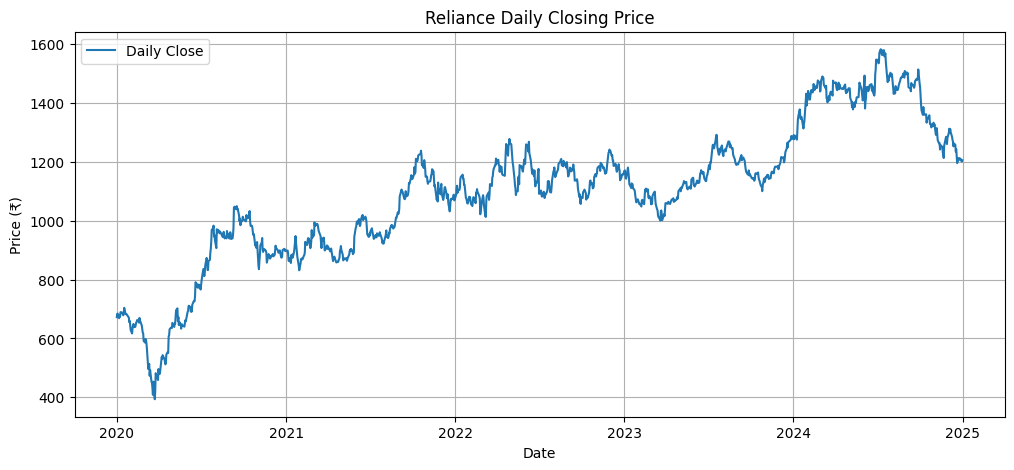

In [17]:
# Plot daily closing prices
plt.figure(figsize=(12,5))

plt.plot(
    reliance.index,
    reliance["Close"],
    label="Daily Close"
)

plt.title("Reliance Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")

plt.legend()
plt.grid(True)

plt.savefig(
    "../images/daily_close.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Weekly Resampling

In [18]:
# Convert daily data into weekly data
weekly = reliance.resample("W").last()

# Display first few rows
weekly.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-05,684.484070,686.487896,678.183128,682.636062,20984698
2020-01-12,689.159668,693.746187,685.597297,691.052144,12478359
2020-01-19,704.010254,705.769146,691.631070,691.764654,29463471
2020-01-26,677.537476,684.127821,676.201572,679.964290,14628445
2020-02-02,628.599609,647.123856,626.618077,647.012506,34750310


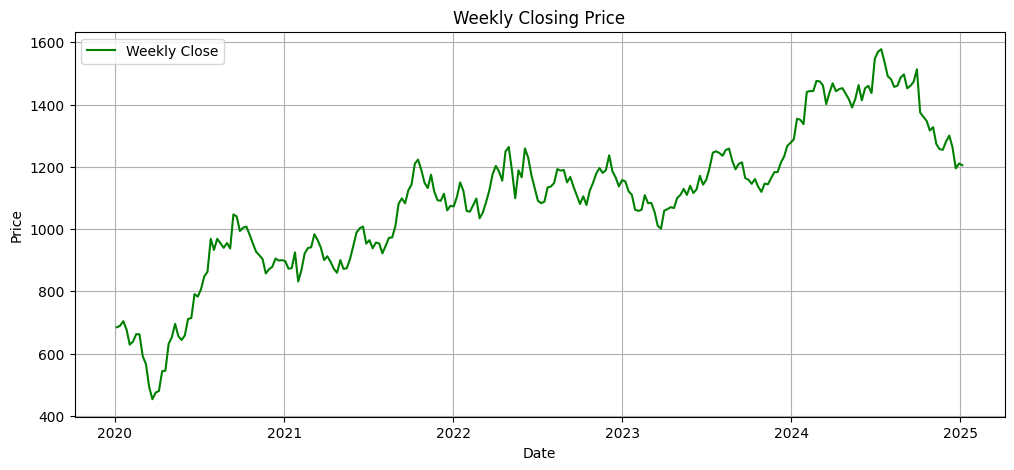

In [19]:
# Plot weekly closing prices
plt.figure(figsize=(12,5))

plt.plot(
    weekly.index,
    weekly["Close"],
    color="green",
    label="Weekly Close"
)

plt.title("Weekly Closing Price")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.savefig(
    "../images/weekly_close.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Weekly Resampling

The `resample("W")` function groups daily observations into weekly intervals.

Using `.last()` selects the final trading day of each week.

## 6. Monthly Resampling

In [20]:
# Convert daily data into monthly data
monthly = reliance.resample("ME").last()

monthly.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-31,628.599609,647.123856,626.618077,647.012506,34750310
2020-02-29,591.640198,604.264316,590.014890,603.329166,39315769
2020-03-31,495.946472,503.093419,466.668378,478.223761,44292810
2020-04-30,652.801392,665.692680,640.355445,647.435600,71345899
2020-05-31,658.270081,661.686383,652.988292,659.888313,40022527


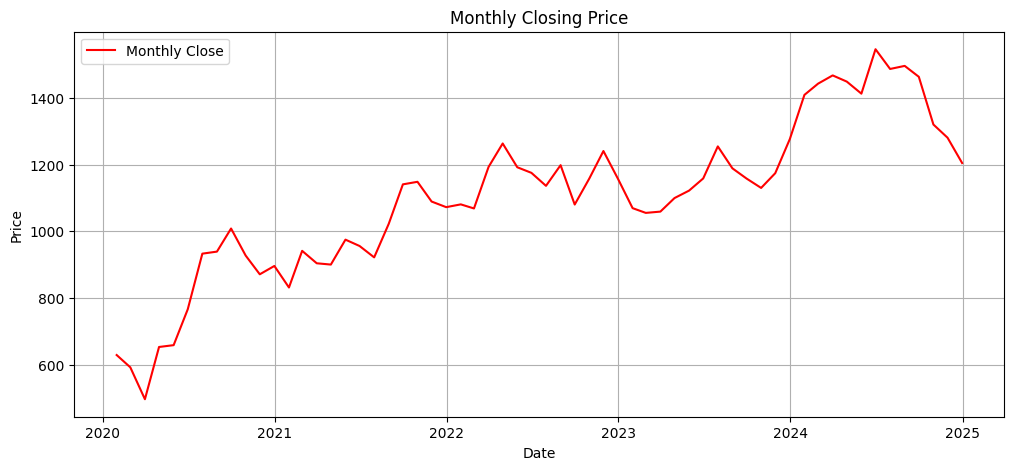

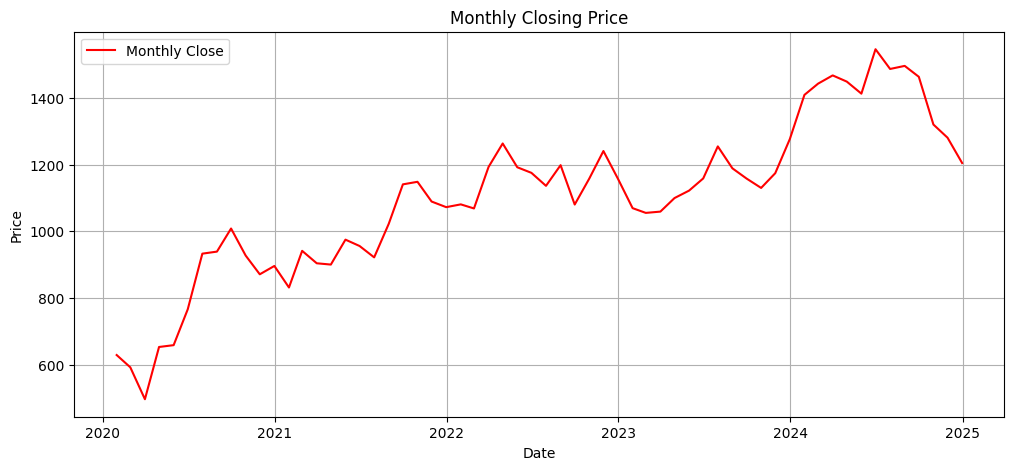

In [ ]:
# Plot monthly closing prices
plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly["Close"],
    color="red",
    label="Monthly Close"
)

plt.title("Monthly Closing Price")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.savefig(
    "../images/monthly_close.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Monthly Resampling

Monthly resampling reduces the daily observations into one observation per month.

This is useful when analysing long-term investment trends.

## 7. Create Lag Features

In [22]:
# Create previous day's closing price
reliance["Lag_1"] = reliance["Close"].shift(1)

# Create previous week's closing price (5 trading days)
reliance["Lag_5"] = reliance["Close"].shift(5)

# Create previous month's closing price (21 trading days)
reliance["Lag_21"] = reliance["Close"].shift(21)

In [23]:
# Display lag features
reliance[
    [
        "Close",
        "Lag_1",
        "Lag_5",
        "Lag_21"
    ]
].head(30)

Price,Close,Lag_1,Lag_5,Lag_21
Ticker,RELIANCE.NS,,,
Date,,,,
2020-01-01,672.216125,NaN,NaN,NaN
2020-01-02,683.660217,672.216125,NaN,NaN
2020-01-03,684.484070,683.660217,NaN,NaN
2020-01-06,668.609375,684.484070,NaN,NaN
2020-01-07,678.895691,668.609375,NaN,NaN
2020-01-08,673.796997,678.895691,672.216125,NaN
2020-01-09,689.315552,673.796997,683.660217,NaN
2020-01-10,689.159668,689.315552,684.484070,NaN


### Why Lag Features?

Lag variables provide information about previous observations.

Examples:

- Lag-1 → Previous trading day
- Lag-5 → Previous trading week
- Lag-21 → Previous trading month

Lag features are widely used in forecasting models because future values often depend on past observations.

## 8. Save Cleaned Dataset

In [24]:
# Save processed dataset for future modeling
reliance.to_csv("cleaned_reliance_timeseries.csv")

print("Dataset saved successfully.")

Dataset saved successfully.


## Conclusion

In this notebook:

- Converted the stock dataset into a DatetimeIndex.
- Resampled daily data into weekly and monthly frequencies.
- Created Lag-1, Lag-5, and Lag-21 features.
- Saved a cleaned dataset ready for time series modeling.

These preprocessing steps prepare the data for forecasting techniques that will be explored in the upcoming lessons.